In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("customer_data.csv")

df.head()

,Customer_ID,Name,Age,Gender,Location,Annual_Income,Purchase_Frequency,Total_Purchases,Average_Order_Value,Total_Spending,Preferred_Category
0,1,Vivek Singh,28,Female,Bengaluru,71875.0,6,9,1904.68,14665.33,Clothing
1,2,Sneha Agarwal,21,Male,Chandigarh,72025.0,5,8,1903.52,16094.51,Clothing
2,3,Kunal Bisht,32,Female,Chandigarh,82024.0,5,8,2245.07,16890.43,Clothing
3,4,Vivek Mishra,23,Other,Bengaluru,89688.0,6,6,3029.12,18861.64,NaN
4,5,Kavya Joshi,47,Female,Noida,78953.0,3,7,2400.34,15040.88,Sports


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (503, 11)

Column Names:
['Customer_ID', 'Name', 'Age', 'Gender', 'Location', 'Annual_Income', 'Purchase_Frequency', 'Total_Purchases', 'Average_Order_Value', 'Total_Spending', 'Preferred_Category']

Data Types:
Customer_ID              int64
Name                       str
Age                      int64
Gender                     str
Location                   str
Annual_Income          float64
Purchase_Frequency       int64
Total_Purchases          int64
Average_Order_Value    float64
Total_Spending         float64
Preferred_Category         str
dtype: object


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          503 non-null    int64  
 1   Name                 503 non-null    str    
 2   Age                  503 non-null    int64  
 3   Gender               503 non-null    str    
 4   Location             501 non-null    str    
 5   Annual_Income        500 non-null    float64
 6   Purchase_Frequency   503 non-null    int64  
 7   Total_Purchases      503 non-null    int64  
 8   Average_Order_Value  501 non-null    float64
 9   Total_Spending       503 non-null    float64
 10  Preferred_Category   500 non-null    str    
dtypes: float64(3), int64(4), str(4)
memory usage: 43.4 KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Customer_ID            0
Name                   0
Age                    0
Gender                 0
Location               2
Annual_Income          3
Purchase_Frequency     0
Total_Purchases        0
Average_Order_Value    2
Total_Spending         0
Preferred_Category     3
dtype: int64


In [6]:
print("Number of Duplicate Records:", df.duplicated().sum())

Number of Duplicate Records: 3


In [7]:
df.describe()

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Total_Purchases,Average_Order_Value,Total_Spending
count,503.000000,503.000000,500.000000,503.000000,503.000000,501.000000,503.000000
mean,249.479125,41.550696,64754.262000,6.071571,9.399602,2200.957984,20763.204334
std,144.701999,13.740368,20700.442457,2.537929,3.480933,797.535906,11173.953339
min,1.000000,18.000000,22000.000000,1.000000,1.000000,500.000000,1638.570000
25%,124.500000,29.000000,50160.250000,4.000000,7.000000,1640.810000,12868.650000
50%,249.000000,42.000000,64676.500000,6.000000,9.000000,2185.080000,18952.630000
75%,374.500000,53.500000,78608.000000,8.000000,12.000000,2799.510000,26617.245000
max,500.000000,65.000000,123817.000000,14.000000,21.000000,4463.600000,73462.410000


In [8]:
df.shape

(503, 11)

In [9]:
df.isnull().sum()

Customer_ID            0
Name                   0
Age                    0
Gender                 0
Location               2
Annual_Income          3
Purchase_Frequency     0
Total_Purchases        0
Average_Order_Value    2
Total_Spending         0
Preferred_Category     3
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(3)

In [11]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (500, 11)


In [12]:
# Fill numerical missing values with the median
df["Annual_Income"] = df["Annual_Income"].fillna(
    df["Annual_Income"].median()
)

df["Average_Order_Value"] = df["Average_Order_Value"].fillna(
    df["Average_Order_Value"].median()
)

# Fill categorical missing values with the mode
df["Location"] = df["Location"].fillna(
    df["Location"].mode()[0]
)

df["Preferred_Category"] = df["Preferred_Category"].fillna(
    df["Preferred_Category"].mode()[0]
)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Customer_ID            0
Name                   0
Age                    0
Gender                 0
Location               0
Annual_Income          0
Purchase_Frequency     0
Total_Purchases        0
Average_Order_Value    0
Total_Spending         0
Preferred_Category     0
dtype: int64


In [13]:
df["Customer_ID"] = df["Customer_ID"].astype(int)
df["Age"] = df["Age"].astype(int)
df["Annual_Income"] = df["Annual_Income"].astype(float)
df["Purchase_Frequency"] = df["Purchase_Frequency"].astype(int)
df["Total_Purchases"] = df["Total_Purchases"].astype(int)
df["Average_Order_Value"] = df["Average_Order_Value"].astype(float)
df["Total_Spending"] = df["Total_Spending"].astype(float)

print(df.dtypes)

Customer_ID              int64
Name                       str
Age                      int64
Gender                     str
Location                   str
Annual_Income          float64
Purchase_Frequency       int64
Total_Purchases          int64
Average_Order_Value    float64
Total_Spending         float64
Preferred_Category         str
dtype: object


In [14]:
print("Final Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Records:", df.duplicated().sum())

Final Shape: (500, 11)
Total Missing Values: 0
Total Duplicate Records: 0


## Analyze Purchasing Behavior

## Q1 — What is the average customer spending?

In [15]:
average_spending = df["Total_Spending"].mean()

print("Average Customer Spending: ₹", round(average_spending, 2))

Average Customer Spending: ₹ 20763.39


## Q2 — Which product category is most popular?

In [16]:
category_counts = df["Preferred_Category"].value_counts()

print(category_counts)

Preferred_Category
Electronics       127
Clothing          100
Home & Kitchen     77
Beauty             71
Sports             64
Books              61
Name: count, dtype: int64


## Q3 — Which location has the most customers?

In [17]:
location_counts = df["Location"].value_counts()

print(location_counts)

Location
Bengaluru     58
Mumbai        56
Dehradun      55
Chandigarh    53
Gurugram      49
Haridwar      48
Noida         46
Jaipur        46
Lucknow       46
Delhi         43
Name: count, dtype: int64


## Q4 — Which location generates the highest total spending?

In [18]:
location_spending = (
    df.groupby("Location")["Total_Spending"]
    .sum()
    .sort_values(ascending=False)
)

print(location_spending)

Location
Mumbai        1255195.13
Bengaluru     1124557.14
Dehradun      1117973.93
Noida         1113174.35
Lucknow       1062499.24
Chandigarh     984886.73
Haridwar       981554.16
Gurugram       963153.53
Jaipur         904688.09
Delhi          874014.04
Name: Total_Spending, dtype: float64


In [19]:
bins = [17, 25, 35, 50, 100]
labels = ["18-25", "26-35", "36-50", "51+"]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df["Age_Group"].value_counts().sort_index()

Age_Group
18-25     84
26-35     97
36-50    160
51+      159
Name: count, dtype: int64

In [20]:
age_group_spending = (
    df.groupby("Age_Group", observed=True)["Total_Spending"]
    .agg(["count", "mean", "sum"])
)

print(age_group_spending)

           count          mean         sum
Age_Group                                 
18-25         84  20775.415952  1745134.94
26-35         97  19647.567938  1905814.09
36-50        160  21323.264813  3411722.37
51+          159  20874.370692  3319024.94


In [21]:
df["Spending_Segment"] = pd.qcut(
    df["Total_Spending"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

print(df["Spending_Segment"].value_counts())

Spending_Segment
Low Value       167
High Value      167
Medium Value    166
Name: count, dtype: int64


In [22]:
segment_analysis = (
    df.groupby("Spending_Segment", observed=True)
    .agg(
        Customers=("Customer_ID", "count"),
        Average_Spending=("Total_Spending", "mean"),
        Total_Revenue=("Total_Spending", "sum"),
        Average_Purchases=("Total_Purchases", "mean"),
        Average_Order_Value=("Average_Order_Value", "mean")
    )
)

print(segment_analysis)

                  Customers  Average_Spending  Total_Revenue  \
Spending_Segment                                               
Low Value               167       9841.077126     1643459.88   
Medium Value            166      19309.261687     3205337.44   
High Value              167      33131.131856     5532899.02   

                  Average_Purchases  Average_Order_Value  
Spending_Segment                                          
Low Value                  6.844311          1632.108982  
Medium Value               9.530120          2175.315542  
High Value                11.826347          2793.273174  


In [23]:
top_customers = (
    df.sort_values("Total_Spending", ascending=False)
    .head(10)
)

print(
    top_customers[
        [
            "Customer_ID",
            "Name",
            "Age",
            "Location",
            "Preferred_Category",
            "Total_Purchases",
            "Total_Spending"
        ]
    ]
)

     Customer_ID            Name  Age    Location Preferred_Category  \
116          117  Tanvi Malhotra   64      Jaipur     Home & Kitchen   
11            12    Aarav Kapoor   62    Dehradun        Electronics   
295          296     Ayush Gupta   46   Bengaluru        Electronics   
496          497     Kunal Patel   32      Mumbai        Electronics   
320          321     Rohan Mehta   38      Jaipur              Books   
259          260   Aditya Kapoor   40      Jaipur             Sports   
115          116     Ananya Negi   32      Mumbai           Clothing   
169          170    Vivaan Patel   64       Delhi        Electronics   
302          303      Diya Kumar   64     Lucknow             Beauty   
441          442    Nikhil Bisht   64  Chandigarh     Home & Kitchen   

     Total_Purchases  Total_Spending  
116               18        73462.41  
11                17        66119.39  
295               14        62737.78  
496               16        62299.76  
320         

In [24]:
frequency_analysis = (
    df.groupby("Purchase_Frequency")["Total_Spending"]
    .agg(["count", "mean", "sum"])
    .sort_index()
)

print(frequency_analysis)

                    count          mean         sum
Purchase_Frequency                                 
1                      12   8305.396667    99664.76
2                      18   8193.064444   147475.16
3                      45  14367.953333   646557.90
4                      79  17211.936456  1359742.98
5                      57  18288.041579  1042418.37
6                      84  21022.705952  1765907.30
7                      70  23302.298429  1631160.89
8                      46  24009.860000  1104453.56
9                      43  27445.637674  1180162.42
10                     23  26887.556087   618413.79
11                     10  35481.465000   354814.65
12                      5  24301.744000   121508.72
13                      6  33934.568333   203607.41
14                      2  52904.215000   105808.43


In [25]:
gender_analysis = (
    df.groupby("Gender")
    .agg(
        Customers=("Customer_ID", "count"),
        Average_Spending=("Total_Spending", "mean"),
        Total_Spending=("Total_Spending", "sum"),
        Average_Purchases=("Total_Purchases", "mean")
    )
    .sort_values("Total_Spending", ascending=False)
)

print(gender_analysis)

        Customers  Average_Spending  Total_Spending  Average_Purchases
Gender                                                                
Male          234      21630.866795      5061622.83           9.769231
Female        244      20073.605492      4897959.74           9.065574
Other          22      19186.989545       422113.77           9.181818


## Visualization
 

## 1: Spending by Age Group

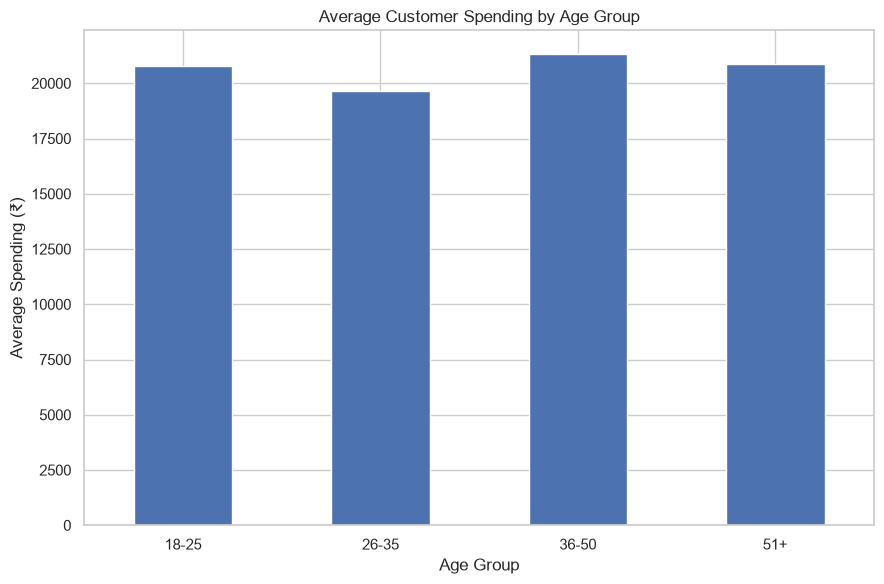

In [26]:
plt.figure(figsize=(9, 6))

age_spending = (
    df.groupby("Age_Group", observed=True)["Total_Spending"]
    .mean()
)

age_spending.plot(kind="bar")

plt.title("Average Customer Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spending (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 2: Revenue by Location

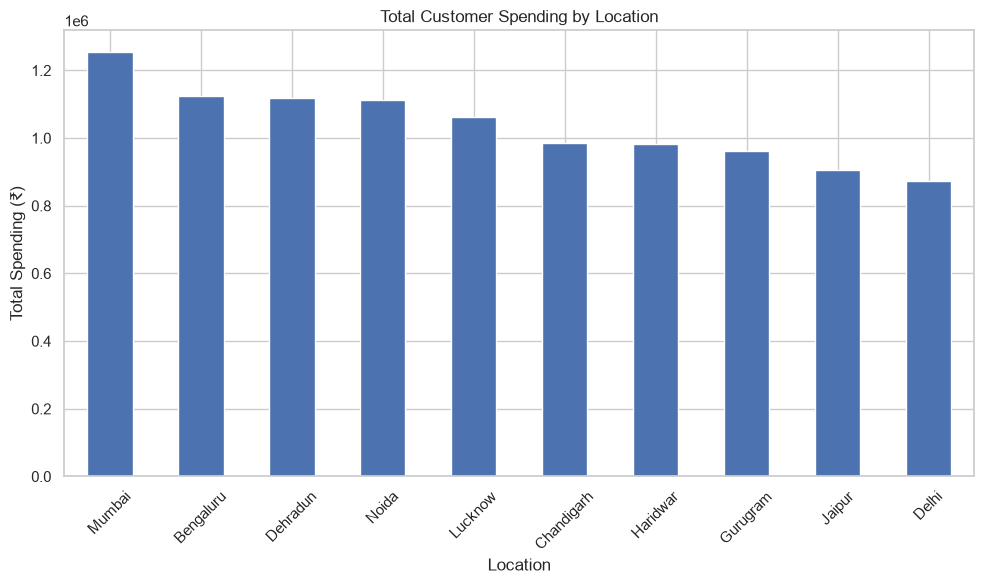

In [27]:
location_revenue = (
    df.groupby("Location")["Total_Spending"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

location_revenue.plot(kind="bar")

plt.title("Total Customer Spending by Location")
plt.xlabel("Location")
plt.ylabel("Total Spending (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3: Customer Distribution by Category

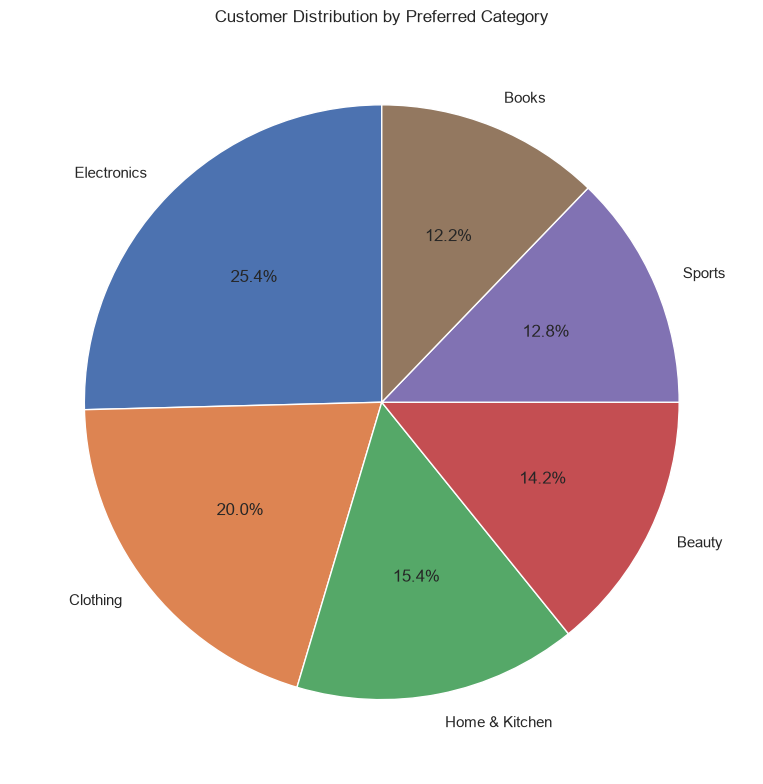

In [28]:
category_counts = df["Preferred_Category"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution by Preferred Category")

plt.tight_layout()
plt.show()

## 4: Customer Value Segments

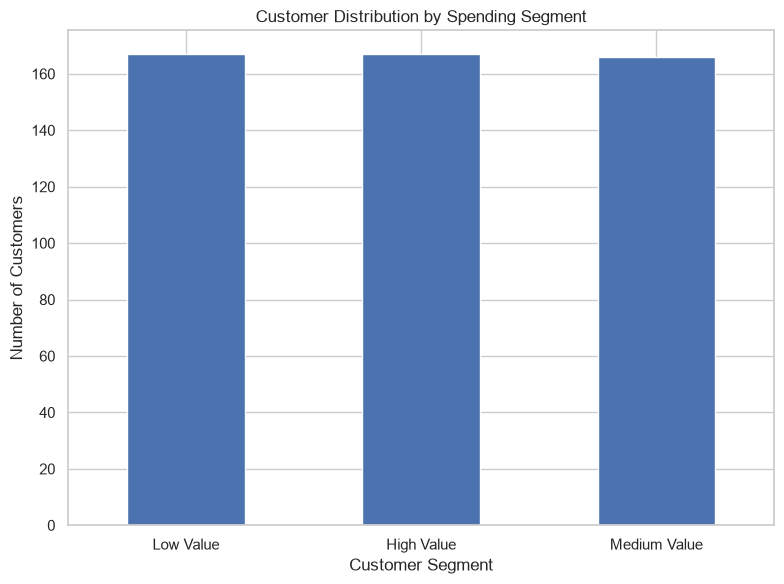

In [29]:
segment_counts = df["Spending_Segment"].value_counts()

plt.figure(figsize=(8, 6))

segment_counts.plot(kind="bar")

plt.title("Customer Distribution by Spending Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 5: Purchase Frequency vs Spending

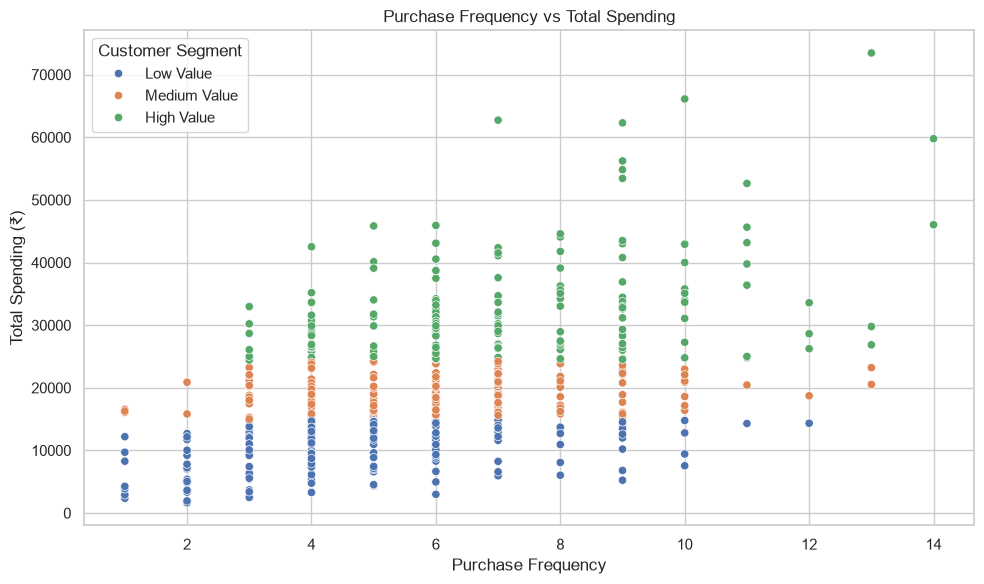

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Purchase_Frequency",
    y="Total_Spending",
    hue="Spending_Segment"
)

plt.title("Purchase Frequency vs Total Spending")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending (₹)")
plt.legend(title="Customer Segment")

plt.tight_layout()
plt.show()

## Correlation Heatmap

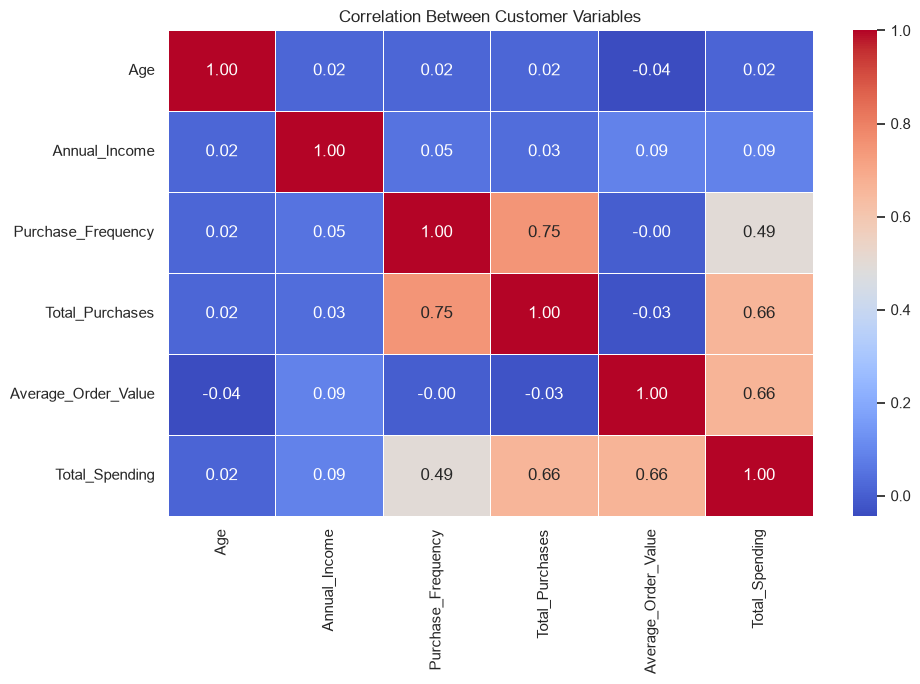

In [31]:
plt.figure(figsize=(10, 7))

numeric_columns = [
    "Age",
    "Annual_Income",
    "Purchase_Frequency",
    "Total_Purchases",
    "Average_Order_Value",
    "Total_Spending"
]

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Customer Variables")

plt.tight_layout()
plt.show()

In [32]:
top_customer = df.loc[df["Total_Spending"].idxmax()]

print(top_customer)

Customer_ID                       117
Name                   Tanvi Malhotra
Age                                64
Gender                           Male
Location                       Jaipur
Annual_Income                 60581.0
Purchase_Frequency                 13
Total_Purchases                    18
Average_Order_Value           3775.81
Total_Spending               73462.41
Preferred_Category     Home & Kitchen
Age_Group                         51+
Spending_Segment           High Value
Name: 116, dtype: object


In [33]:
segment_revenue = (
    df.groupby("Spending_Segment", observed=True)["Total_Spending"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Spending_Segment
High Value      5532899.02
Medium Value    3205337.44
Low Value       1643459.88
Name: Total_Spending, dtype: float64


In [34]:
location_average = (
    df.groupby("Location")["Total_Spending"]
    .mean()
    .sort_values(ascending=False)
)

print(location_average)

Location
Noida         24199.442391
Lucknow       23097.809565
Mumbai        22414.198750
Haridwar      20449.045000
Dehradun      20326.798727
Delhi         20325.907907
Jaipur        19667.132391
Gurugram      19656.194490
Bengaluru     19388.916207
Chandigarh    18582.768491
Name: Total_Spending, dtype: float64


In [35]:
category_revenue = (
    df.groupby("Preferred_Category")["Total_Spending"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

Preferred_Category
Electronics       2787451.26
Clothing          2003327.07
Home & Kitchen    1604218.92
Beauty            1392608.05
Sports            1342398.25
Books             1251692.79
Name: Total_Spending, dtype: float64
